# Clustering Countries using Unsupervised Learning
### HELP International - Country Aid Priority

HELP International has raised about $10 million and wants to know which countries need this aid the most. In this notebook I use K-Means and DBSCAN clustering on socio-economic and health data to group countries by development level, then figure out which ones should be prioritized.


## Step 1: Install required libraries

## Step 2: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')


## Step 3: Upload the dataset

In [3]:

try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not in Colab, skipping upload - reading file directly")


Not in Colab, skipping upload - reading file directly


In [4]:
df = pd.read_csv('Country-data.csv')
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.shape


(167, 10)

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [7]:
df.describe()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Step 4: Clean the data

Before doing anything else I need to clean up the dataset a bit - remove extra spaces in column names, drop any duplicate rows, make sure all the number columns are actually numbers, and fill any missing values with the median.


In [8]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.median(numeric_only=True))

df.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## Step 5: A quick look at the data before clustering

Just to get a feel for the data, I checked how the features relate to each other with a correlation heatmap.


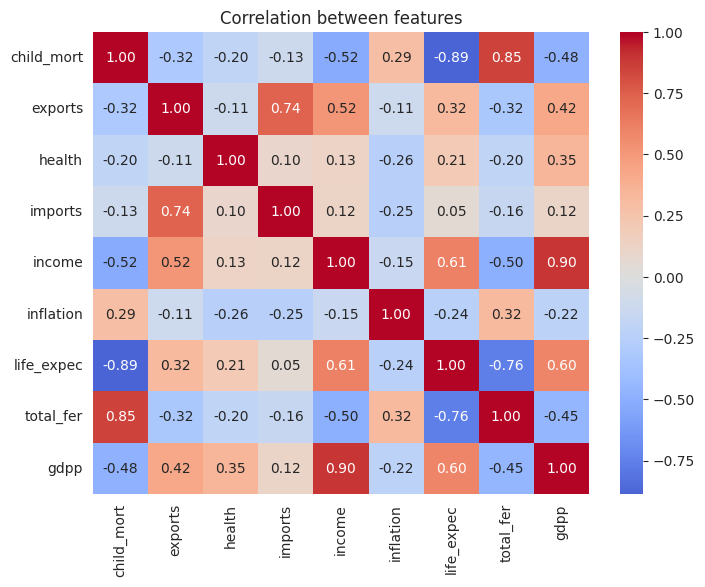

In [9]:
numeric_cols = [c for c in df.columns if c != 'country']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between features')
plt.show()


child_mort and total_fer move together, and both are negatively correlated with income, gdpp and life_expec. Basically, poorer countries tend to have higher child mortality and higher fertility rates, and richer countries have longer life expectancy. This is a good sign that clustering on these features should actually separate countries by development level.


## Step 6: Scale the features

The country column is just a name so it needs to be separated out before scaling. The rest of the columns are on different scales (income is in thousands, health is a percentage) so I use StandardScaler to bring them all to the same range.


In [10]:
country_names = df['country']
features = df.drop('country', axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]


array([[ 1.29153238, -1.13827979,  0.27908825, -0.08245496, -0.8082454 ,
         0.15733622, -1.61909203,  1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618,  0.07083669, -0.3753689 ,
        -0.31234747,  0.64786643, -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, -0.64176233, -0.22084447,
         0.78927429,  0.67042323, -0.0384044 , -0.46537561],
       [ 2.00780766,  0.77538117, -1.44807093, -0.16531531, -0.58504345,
         1.38705353, -1.17923442,  2.12815103, -0.51626829],
       [-0.69563412,  0.1606679 , -0.28689415,  0.4975675 ,  0.10173177,
        -0.60174853,  0.70425843, -0.54194633, -0.04181713]])

## Step 7: Elbow method

To pick the right number of clusters I run K-Means for k = 2 to 10 and plot the inertia for each one. Wherever the curve starts to flatten is usually a good choice for k.


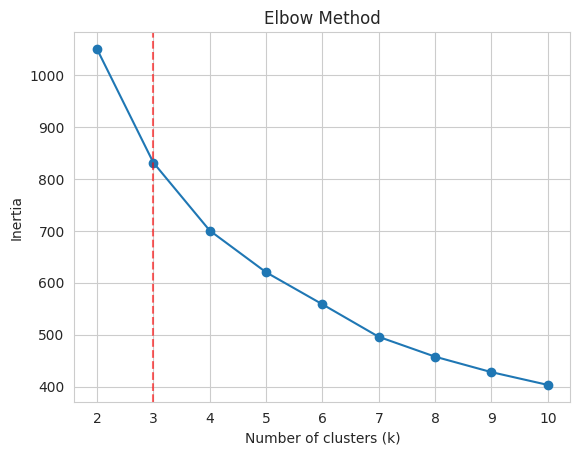

In [11]:
inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6)
plt.show()


The elbow bends around k = 3, so that's what I'll use going forward.

## Step 8: K-Means clustering (k = 3)

In [12]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


## Step 9: Silhouette score

In [13]:
score = silhouette_score(scaled_features, clusters)
print("Silhouette Score:", round(score, 4))


Silhouette Score: 0.2833


A score around 0.25-0.3 isn't super high but it's normal for real socio-economic data since countries don't fall into perfectly separated groups - development is more of a spectrum.

## Step 10: DBSCAN clustering (comparison)

Just to compare against K-Means, I also tried DBSCAN with eps = 1.5 and min_samples = 5.


In [14]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(scaled_features)

df['DBSCAN_Cluster'] = dbscan_clusters
df['DBSCAN_Cluster'].value_counts()


DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

DBSCAN mostly puts everything into one big cluster and marks a handful of countries as noise (-1). This makes sense because DBSCAN looks for dense separated groups, but country data changes gradually rather than forming isolated clusters. K-Means handles this kind of data better, so I'm sticking with the K-Means clusters for the rest of the analysis.

## Step 11: PCA visualization

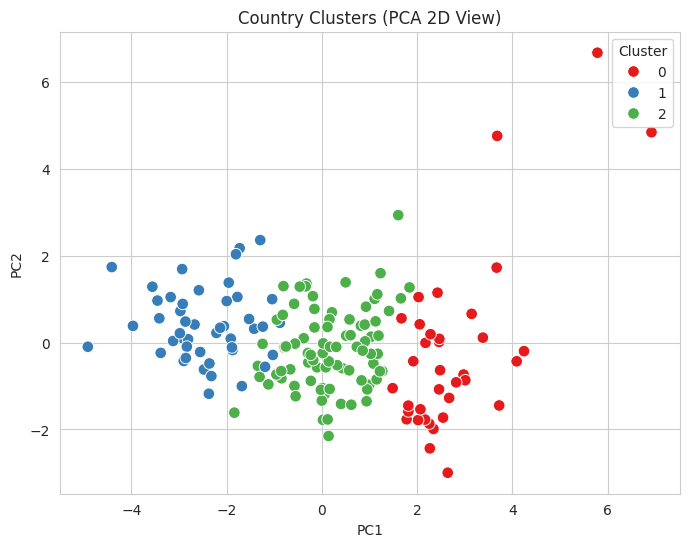

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=70)
plt.title('Country Clusters (PCA 2D View)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Step 12: Naming the clusters

Now that the clusters are formed, I want to know which one is which. I'll rank the clusters by gdpp (GDP per person) so I can label the lowest one as needing the most aid, and the highest one as the most developed.


In [16]:
cluster_avg = df.groupby('Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
cluster_avg


,child_mort,income,gdpp,life_expec
Cluster,,,,
0,5.000000,45672.222222,42494.444444,80.127778
1,92.961702,3942.404255,1922.382979,59.187234
2,21.927381,12305.595238,6486.452381,72.814286


In [17]:
# rank clusters by gdpp so we know which one is which
order = df.groupby('Cluster')['gdpp'].mean().sort_values().index.tolist()

labels = {
    order[0]: 'Under-Developed (needs aid)',
    order[1]: 'Developing',
    order[2]: 'Developed'
}

df['Development_Level'] = df['Cluster'].map(labels)
df['Development_Level'].value_counts()


Development_Level
Developing                     84
Under-Developed (needs aid)    47
Developed                      36
Name: count, dtype: int64

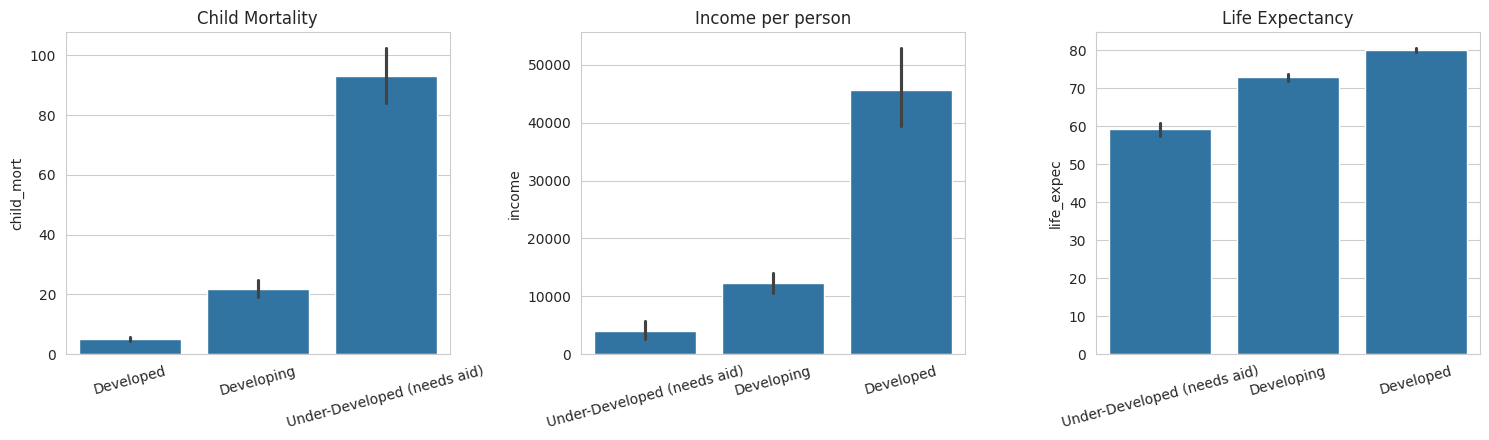

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['child_mort', 'income', 'life_expec']
titles = ['Child Mortality', 'Income per person', 'Life Expectancy']

for ax, metric, title in zip(axes, metrics, titles):
    order_x = df.groupby('Development_Level')[metric].mean().sort_values().index
    sns.barplot(x='Development_Level', y=metric, data=df, order=order_x, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## Step 13: Which countries need aid the most?

In [19]:
priority_countries = df[df['Development_Level'] == 'Under-Developed (needs aid)']
priority_countries = priority_countries.sort_values('gdpp')[['country', 'child_mort', 'income', 'gdpp', 'life_expec']]
priority_countries.head(10)


,country,child_mort,income,gdpp,life_expec
26,Burundi,93.6,764,231,57.7
88,Liberia,89.3,700,327,60.8
37,"Congo, Dem. Rep.",116.0,609,334,57.5
112,Niger,123.0,814,348,58.8
132,Sierra Leone,160.0,1220,399,55.0
93,Madagascar,62.2,1390,413,60.8
106,Mozambique,101.0,918,419,54.5
31,Central African Republic,149.0,888,446,47.5
94,Malawi,90.5,1030,459,53.1
50,Eritrea,55.2,1420,482,61.7


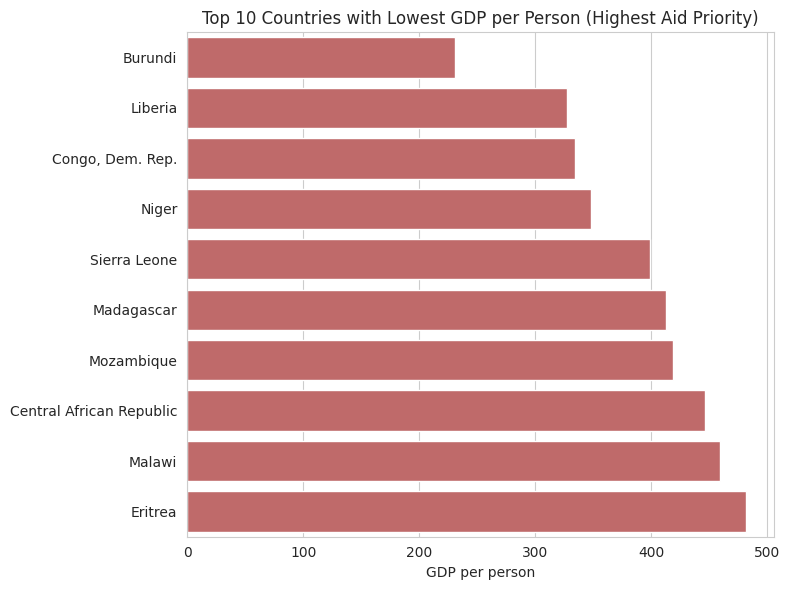

In [20]:
plt.figure(figsize=(8, 6))
top10 = priority_countries.head(10)
sns.barplot(x='gdpp', y='country', data=top10, color='indianred')
plt.title('Top 10 Countries with Lowest GDP per Person (Highest Aid Priority)')
plt.xlabel('GDP per person')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Section 14: Observations

1. One cluster has really high child mortality and low life expectancy compared to the other two - these countries are struggling the most in terms of basic health outcomes. This is the "Under-Developed" cluster.

2. Another cluster has high income and gdpp along with low child mortality - these are the "Developed" countries and probably don't need aid.

3. The third cluster sits in the middle - not as poor as the first group but not developed either, so these countries are still "Developing".

4. When sorted by gdpp within the under-developed cluster, countries like Burundi, Liberia, Congo, Niger and Sierra Leone come out at the bottom, so these should be looked at first for aid.

5. K-Means gave cleaner and more balanced groups than DBSCAN for this dataset - DBSCAN just grouped almost everything together and flagged a few outliers, so it wasn't as useful for actually splitting countries into aid categories.

**Conclusion:** Based on this clustering, HELP International should direct most of the $10 million toward the countries in the Under-Developed cluster, especially the ones with the lowest gdpp and income combined with the highest child mortality, like the ones shown in the chart above.
